# TFM - Baseline CNN para clasificación de defectos (NEU-DET)

Este notebook implementa un modelo *baseline* de clasificación de imágenes con PyTorch para las 6 clases del dataset NEU-DET: `crazing`, `inclusion`, `patches`, `pitted_surface`, `rolled-in_scale` y `scratches`.

La tubería incluye: carga de datos con `ImageFolder`, partición entrenamiento/validación (80/20), definición de una CNN personalizada y entrenamiento con monitorización de *loss* y *accuracy*.

In [1]:
# ============================
# 1) Importaciones y configuración
# ============================
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Fijamos semillas para mejorar la reproducibilidad de los experimentos.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Selección automática de dispositivo: GPU si está disponible, en caso contrario CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo en uso: {device}')

Dispositivo en uso: cuda


In [2]:
# ==========================================
# 2) Transformaciones y carga del dataset
# ==========================================
# Ruta relativa desde la carpeta notebooks/ hacia el dataset organizado por clase.
data_dir = Path('../data/clasificacion_full')

# Transformaciones de entrenamiento con data augmentation.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones de validación (sin augmentation para evaluación objetiva).
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset base para extraer clases y etiquetas.
base_dataset = datasets.ImageFolder(root=data_dir)
class_names = base_dataset.classes
num_classes = len(class_names)

print(f'Total de imágenes: {len(base_dataset)}')
print(f'Número de clases: {num_classes}')
print(f'Clases detectadas: {class_names}')

Total de imágenes: 1439
Número de clases: 6
Clases detectadas: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [3]:
# ==================================================
# 3) División Train/Validation y DataLoaders
# ==================================================
targets = np.array(base_dataset.targets)
indices = np.arange(len(base_dataset))

# División estratificada para conservar la proporción de clases en train y validación.
train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=targets
)

# Creamos dos versiones del dataset para aplicar transformaciones distintas.
train_dataset_full = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_dataset_full = datasets.ImageFolder(root=data_dir, transform=val_transform)

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(val_dataset_full, val_indices)

batch_size = 32
num_workers = 0  # En Windows suele ser más estable comenzar con 0.

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

print(f'Muestras de entrenamiento: {len(train_dataset)}')
print(f'Muestras de validación: {len(val_dataset)}')

Muestras de entrenamiento: 1151
Muestras de validación: 288


In [4]:
# ===============================================
# 4) Definición de la CNN baseline personalizada
# ===============================================
class CustomSteelCNN(nn.Module):
    """
    CNN mejorada para clasificación multiclase en NEU-DET.
    Arquitectura: 3 bloques Conv + BatchNorm + ReLU + MaxPool,
    seguidos de un clasificador denso con regularización Dropout.
    """

    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Reduce el mapa espacial para contener el número de parámetros.
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CustomSteelCNN(num_classes=num_classes).to(device)
print(model)

CustomSteelCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (

In [5]:
# =============================================
# 5) Función de pérdida, optimizador y scheduler
# =============================================
criterion = nn.CrossEntropyLoss()

# Adam con weight decay para mejorar la generalización.
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Reduce el learning rate cuando la pérdida de validación se estanca.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print('Configuración de entrenamiento:')
print(f'- Loss: {criterion.__class__.__name__}')
print(f'- Optimizador: {optimizer.__class__.__name__}')
print('- Scheduler: ReduceLROnPlateau')

Configuración de entrenamiento:
- Loss: CrossEntropyLoss
- Optimizador: Adam
- Scheduler: ReduceLROnPlateau


In [6]:
# =========================================================
# 6) Funciones auxiliares para entrenar y validar por epoch
# =========================================================
def run_epoch(model, dataloader, criterion, optimizer=None, device='cpu'):
    """
    Ejecuta una época de entrenamiento o validación.
    Si 'optimizer' es None, realiza solo validación.
    Retorna loss, accuracy y métricas macro (precision, recall, f1).
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.set_grad_enabled(is_train):
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            preds = torch.argmax(outputs, dim=1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_corrects += (preds == labels).sum().item()
            total_samples += batch_size

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples

    # Calcular métricas macro (precisión, recall, F1) por época.
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )

    return epoch_loss, epoch_acc, precision_macro, recall_macro, f1_macro

In [7]:
# ==============================================
# 7) Bucle principal de entrenamiento con Early Stopping
# ==============================================
num_epochs = 15
patience = 10
patience_counter = 0

history = {
    'train_loss': [],
    'train_acc': [],
    'train_precision_macro': [],
    'train_recall_macro': [],
    'train_f1_macro': [],
    'val_loss': [],
    'val_acc': [],
    'val_precision_macro': [],
    'val_recall_macro': [],
    'val_f1_macro': [],
    'lr': []
}

best_val_acc = 0.0
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    train_loss, train_acc, train_prec, train_rec, train_f1 = run_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc, val_prec, val_rec, val_f1 = run_epoch(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        optimizer=None,
        device=device
    )

    # Actualizamos scheduler en función de la pérdida de validación.
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_precision_macro'].append(train_prec)
    history['train_recall_macro'].append(train_rec)
    history['train_f1_macro'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision_macro'].append(val_prec)
    history['val_recall_macro'].append(val_rec)
    history['val_f1_macro'].append(val_f1)
    history['lr'].append(current_lr)

    # Guardamos el mejor estado según accuracy de validación.
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0  # Reiniciamos contador de paciencia.
    else:
        patience_counter += 1

    print(
        f'Epoch [{epoch + 1}/{num_epochs}] | '
        f'LR: {current_lr:.6f} | '
        f'Train [Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}] | '
        f'Val [Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}]'
    )

    # Early Stopping: si la pérdida de validación no mejora durante 'patience' epochs, paramos.
    if patience_counter >= patience:
        print(f'\nEarly Stopping activado en epoch {epoch + 1}/{num_epochs}.')
        break

# Restauramos el mejor modelo encontrado durante el entrenamiento.
model.load_state_dict(best_model_state)
print(f'Mejor Val Acc: {best_val_acc:.4f}')

Epoch [1/15] | LR: 0.001000 | Train [Loss: 1.3413, Acc: 0.4509, F1: 0.4401] | Val [Loss: 1.3143, Acc: 0.4167, F1: 0.3600]
Epoch [2/15] | LR: 0.001000 | Train [Loss: 0.8251, Acc: 0.6777, F1: 0.6783] | Val [Loss: 0.6190, Acc: 0.7188, F1: 0.6812]
Epoch [3/15] | LR: 0.001000 | Train [Loss: 0.7830, Acc: 0.6977, F1: 0.6935] | Val [Loss: 0.5113, Acc: 0.7778, F1: 0.7691]
Epoch [4/15] | LR: 0.001000 | Train [Loss: 0.6202, Acc: 0.7394, F1: 0.7378] | Val [Loss: 0.9092, Acc: 0.7535, F1: 0.7558]
Epoch [5/15] | LR: 0.001000 | Train [Loss: 0.6635, Acc: 0.7533, F1: 0.7509] | Val [Loss: 0.4795, Acc: 0.7743, F1: 0.7473]
Epoch [6/15] | LR: 0.001000 | Train [Loss: 0.5829, Acc: 0.7793, F1: 0.7774] | Val [Loss: 0.3552, Acc: 0.8681, F1: 0.8663]
Epoch [7/15] | LR: 0.001000 | Train [Loss: 0.5377, Acc: 0.7976, F1: 0.7974] | Val [Loss: 0.6204, Acc: 0.7917, F1: 0.7893]
Epoch [8/15] | LR: 0.001000 | Train [Loss: 0.4808, Acc: 0.8306, F1: 0.8291] | Val [Loss: 0.2920, Acc: 0.8924, F1: 0.8922]
Epoch [9/15] | LR: 0.001

In [8]:
# ==============================================
# 8) Guardado del mejor modelo entrenado
# ==============================================
output_model_path = Path('../src/custom_steel_cnn_baseline_best.pth')
output_model_path.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        'model_state_dict': model.state_dict(),
        'class_names': class_names,
        'best_val_acc': best_val_acc,
        'history': history
    },
    output_model_path
)

print(f'Mejor modelo guardado en: {output_model_path.resolve()}')

Mejor modelo guardado en: C:\Users\Usuario\Desktop\TFM_CNN_Custom\src\custom_steel_cnn_baseline_best.pth


## Evaluación visual del entrenamiento

Las siguientes celdas permiten analizar el comportamiento del modelo mediante curvas de aprendizaje, evolución del learning rate y matriz de confusión sobre el conjunto de validación.

Gráfica guardada en: ..\resultados\baseline_cnn\curvas_aprendizaje.png


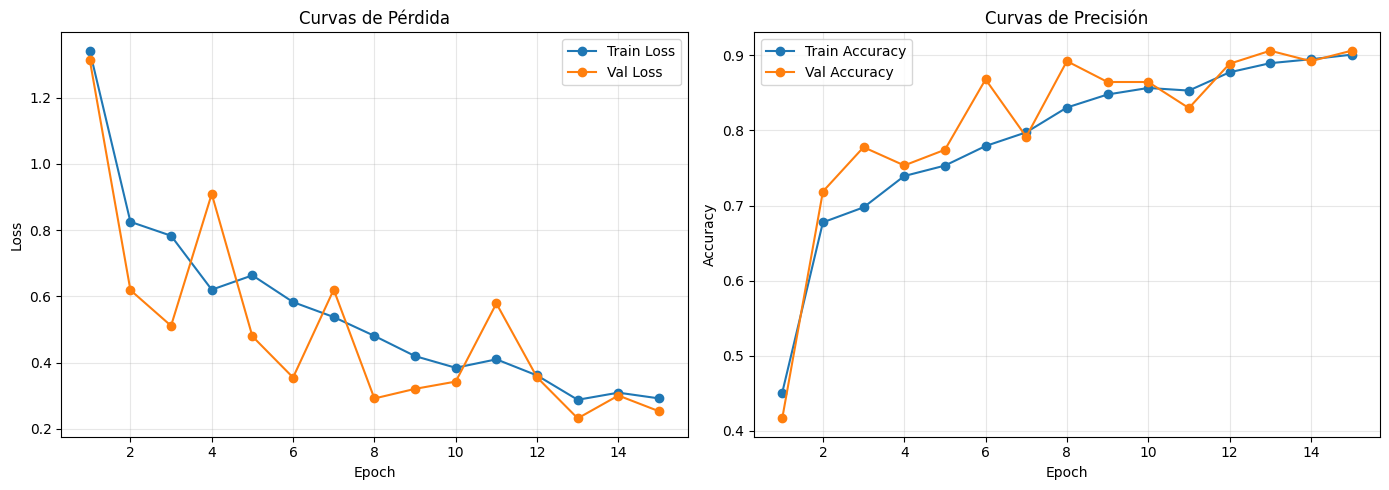

Gráfica guardada en: ..\resultados\baseline_cnn\evolucion_lr.png


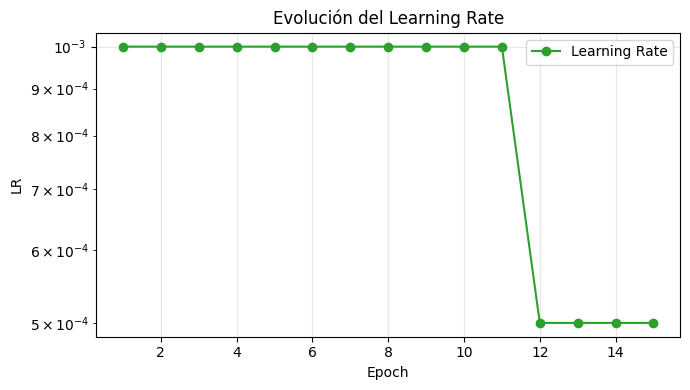

Gráfica guardada en: ..\resultados\baseline_cnn\metricas_macro.png


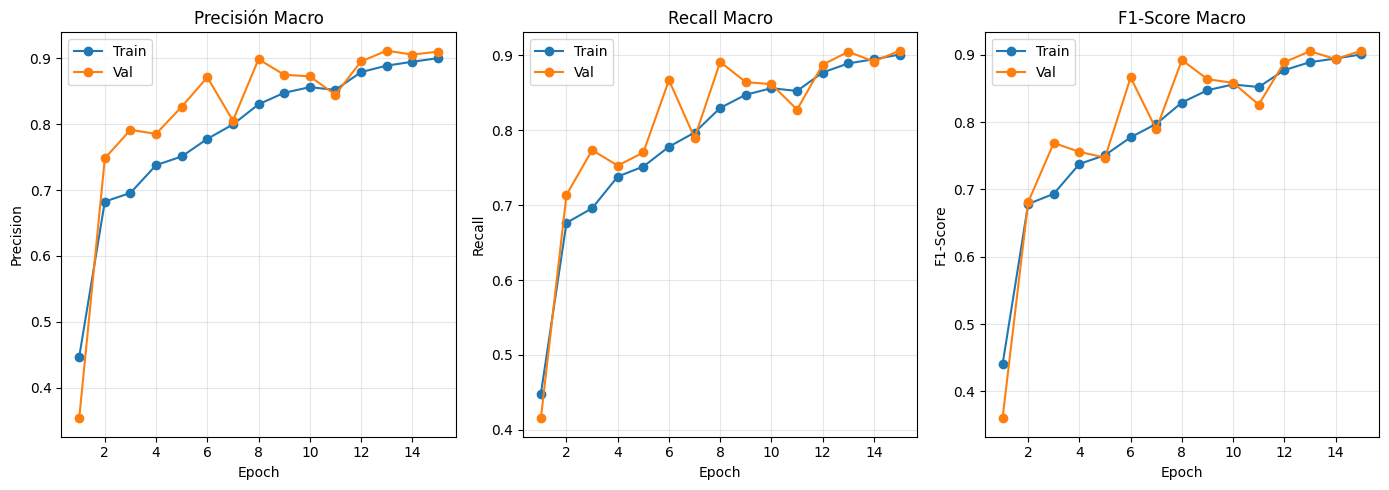

In [9]:
# ==============================================
# 9) Curvas de aprendizaje (Loss y Accuracy) con exportación
# ==============================================
# Crear directorio de resultados si no existe.
results_dir = Path('../resultados/baseline_cnn/')
results_dir.mkdir(parents=True, exist_ok=True)

# Solo usamos epochs hasta donde se detuvo el entrenamiento.
num_epochs_trained = len(history['train_loss'])
epochs = np.arange(1, num_epochs_trained + 1)

# Figura 1: Curvas de pérdida y precisión.
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
plt.title('Curvas de Pérdida')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(epochs, history['val_acc'], label='Val Accuracy', marker='o')
plt.title('Curvas de Precisión')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
learning_curves_path = results_dir / 'curvas_aprendizaje.png'
plt.savefig(learning_curves_path, dpi=300, bbox_inches='tight')
print(f'Gráfica guardada en: {learning_curves_path}')
plt.show()

# Figura 2: Evolución del Learning Rate.
plt.figure(figsize=(7, 4))
plt.plot(epochs, history['lr'], label='Learning Rate', marker='o', color='tab:green')
plt.title('Evolución del Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
lr_path = results_dir / 'evolucion_lr.png'
plt.savefig(lr_path, dpi=300, bbox_inches='tight')
print(f'Gráfica guardada en: {lr_path}')
plt.show()

# Figura 3: Curvas de métricas macro (Precision, Recall, F1).
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, history['train_precision_macro'], label='Train', marker='o')
plt.plot(epochs, history['val_precision_macro'], label='Val', marker='o')
plt.title('Precisión Macro')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, history['train_recall_macro'], label='Train', marker='o')
plt.plot(epochs, history['val_recall_macro'], label='Val', marker='o')
plt.title('Recall Macro')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, history['train_f1_macro'], label='Train', marker='o')
plt.plot(epochs, history['val_f1_macro'], label='Val', marker='o')
plt.title('F1-Score Macro')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
metrics_path = results_dir / 'metricas_macro.png'
plt.savefig(metrics_path, dpi=300, bbox_inches='tight')
print(f'Gráfica guardada en: {metrics_path}')
plt.show()

Matriz de confusión guardada en: ..\resultados\baseline_cnn\matriz_confusion.png


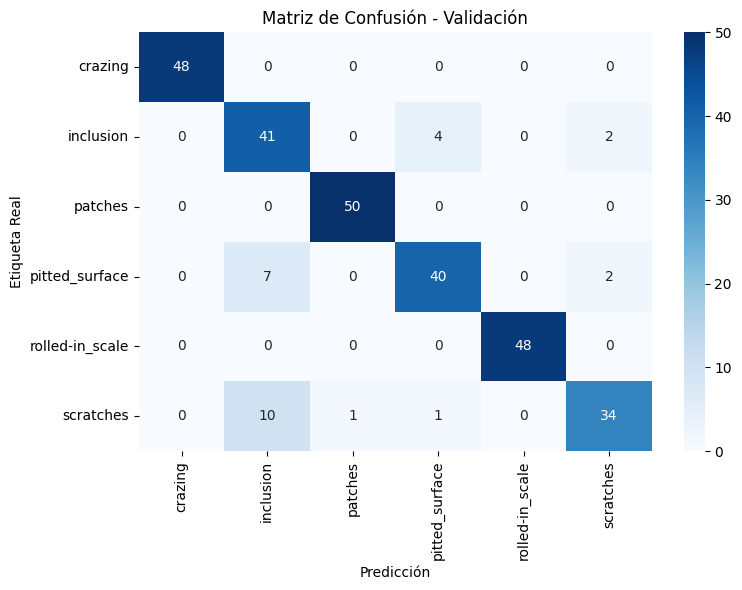

Reporte de clasificación (validación):
                 precision    recall  f1-score   support

        crazing     1.0000    1.0000    1.0000        48
      inclusion     0.7069    0.8723    0.7810        47
        patches     0.9804    1.0000    0.9901        50
 pitted_surface     0.8889    0.8163    0.8511        49
rolled-in_scale     1.0000    1.0000    1.0000        48
      scratches     0.8947    0.7391    0.8095        46

       accuracy                         0.9062       288
      macro avg     0.9118    0.9046    0.9053       288
   weighted avg     0.9130    0.9062    0.9068       288

Reporte guardado en: ..\resultados\baseline_cnn\reporte_clasificacion.txt


In [10]:
# ==============================================
# 10) Matriz de confusión y reporte de clasificación con exportación
# ==============================================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Matriz de Confusión - Validación')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.tight_layout()
cm_path = results_dir / 'matriz_confusion.png'
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f'Matriz de confusión guardada en: {cm_path}')
plt.show()

print('Reporte de clasificación (validación):')
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

# Guardar reporte como texto en archivo.
report_path = results_dir / 'reporte_clasificacion.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)
print(f'Reporte guardado en: {report_path}')

In [ ]:
# ==============================================
# 11) Evaluación final en set TEST externo (no usado en entrenamiento)
# ==============================================
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

if 'results_dir' not in globals():
    results_dir = Path('../resultados/baseline_cnn/')
    results_dir.mkdir(parents=True, exist_ok=True)

test_dir = Path('../data/test')
if not test_dir.exists():
    raise FileNotFoundError(f'No existe la carpeta de test: {test_dir.resolve()}')

test_dataset = ImageFolder(root=str(test_dir), transform=val_transform)

# Validar que las clases del test coincidan con las clases del entrenamiento.
if set(test_dataset.classes) != set(class_names):
    raise ValueError(
        f'Clases distintas entre train y test. train={class_names}, test={test_dataset.classes}'
    )

train_class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_map_test_to_train = {
    test_idx: train_class_to_idx[class_name]
    for class_name, test_idx in test_dataset.class_to_idx.items()
}

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        mapped_labels = [idx_map_test_to_train[int(l)] for l in labels.numpy()]

        test_preds.extend(preds)
        test_labels.extend(mapped_labels)

test_acc = accuracy_score(test_labels, test_preds)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    test_labels,
    test_preds,
    average='macro',
    zero_division=0,
)

print('Resultados en TEST externo:')
print(f'Accuracy:  {test_acc:.4f}')
print(f'Precision macro: {prec_macro:.4f}')
print(f'Recall macro:    {rec_macro:.4f}')
print(f'F1 macro:        {f1_macro:.4f}')

cm_test = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('Matriz de Confusión - TEST externo')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.tight_layout()

test_results_dir = results_dir / 'evaluacion_test'
test_results_dir.mkdir(parents=True, exist_ok=True)

cm_test_path = test_results_dir / 'matriz_confusion_test.png'
plt.savefig(cm_test_path, dpi=300, bbox_inches='tight')
print(f'Matriz de confusión test guardada en: {cm_test_path}')
plt.show()

report_test = classification_report(
    test_labels,
    test_preds,
    target_names=class_names,
    digits=4,
)
print('Reporte de clasificación (TEST):')
print(report_test)

report_test_path = test_results_dir / 'reporte_clasificacion_test.txt'
with open(report_test_path, 'w', encoding='utf-8') as f:
    f.write(report_test)
print(f'Reporte de test guardado en: {report_test_path}')

## Nota metodológica

Este baseline proporciona un punto de referencia para la memoria del TFM. Como siguiente etapa, se recomienda comparar este resultado con arquitecturas preentrenadas (por ejemplo, ResNet o EfficientNet) y con estrategias de *data augmentation* para evaluar la mejora relativa en generalización.